# PoTeC — Potsdam Textbook Corpus: Practical Data Overview

**PoTeC** is a German naturalistic eye-tracking-while-reading corpus. 75 participants (expert/beginner
students of *physics* and *biology*) read 12 short textbook texts (6 physics, 6 biology) while their eye
movements were recorded.

**2×2×2 fully-crossed factorial design**
- *Factor 1 (between):* reader discipline — physics / biology
- *Factor 2 (between):* reader level of study — beginner (undergrad) / expert (graduate)
- *Factor 3 (within):* text domain — physics / biology

The discipline×domain crossing gives **expert reading** (reader's discipline == text domain) vs
**non-expert reading** — the core manipulation.

### Resources
- Paper (Behavior Research Methods, 2024): https://link.springer.com/article/10.3758/s13428-024-02536-8
- Preprint: https://arxiv.org/abs/2403.00506
- GitHub (this repo): https://github.com/DiLi-Lab/PoTeC
- OSF data: https://osf.io/dn5hp/
- `pymovements` library: https://pymovements.readthedocs.io — PoTeC is a built-in public dataset
- `pymovements` PoTeC API: https://pymovements.readthedocs.io/en/stable/

> ⚠️ **Known bug**: the surprisal estimation (`*_surprisal_*` columns) has a known error. Contact the
> authors before using surprisal values. See the paper for contact details.

### Data formats provided per (reader × text)
| folder | content |
|---|---|
| `eyetracking_data/raw_data/` | one gaze sample per line (905 files — incl. reader 9 partial) |
| `eyetracking_data/fixations/` | fixations mapped to characters, calibration-drift corrected |
| `eyetracking_data/reading_measures_merged/` | word-level reading measures + word features + reader info |
| `eyetracking_data/scanpaths_merged/` | fixations ordered temporally + same merges |
| `stimuli/word_features/` | psycholinguistic word features per text |
| `participants/` | demographics + comprehension/background-question accuracy |

> **Note**: reader 9 completed only 5 trials (poor calibration) → 900 merged files, 905 raw.


## 1. Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)

ROOT = Path.cwd()
ET   = ROOT / "eyetracking_data"
RM   = ET / "reading_measures_merged"
FIX  = ET / "fixations"
SP   = ET / "scanpaths_merged"
WF   = ROOT / "stimuli" / "word_features"
print("root:", ROOT)
assert RM.exists(), "run this notebook from the repo root (potec/)"


root: /home/ely/Documents/vault/04-lang-comp-cog/potec


In [2]:
# The German text p3 contains the word "null" -> pandas would read it as NaN.
# Always read PoTeC tsv with default-NA disabled + the explicit NA tokens used by the corpus.
_NA = ['#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan',
       '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NaN', 'None', 'n/a', 'nan', '']

def read_potec(path, **kw):
    return pd.read_csv(path, sep="\t", keep_default_na=False, na_values=_NA, **kw)


## 2. Participants — the 2×2×2 design

In [3]:
participants = read_potec(ROOT / "participants" / "participant_data.tsv")
print("n participants:", len(participants))
participants.head()


n participants: 75


,reader_id,reader_discipline,reader_discipline_numeric,level_of_studies,level_of_studies_numeric,discipline_level_of_studies,discipline_level_of_studies_numeric,glasses,age,handedness,hours_sleep,alcohol,gender,gender_numeric,semester,bilingual,state,grade,subject_detailed
0,0,physics,1,graduate,1,physics-graduate,3,yes,26.0,right,8.0,no,female,1.0,9. FA Master Klimaphysik,n,Brandenburg,"1,9",Physik
1,1,physics,1,graduate,1,physics-graduate,3,yes,NaN,right,6.5,no,male,0.0,5. FA Master,n,Brandenburg,NaN,Physik
2,2,physics,1,graduate,1,physics-graduate,3,yes,26.0,right,7.5,no,female,1.0,Doktorandin,n,Brandenburg,"1,4",Physik
3,3,physics,1,graduate,1,physics-graduate,3,yes,26.0,right,6.5,no,male,0.0,Doktorand,n,Brandenburg,1,Physik
4,4,physics,1,graduate,1,physics-graduate,3,no,25.0,right,7.0,no,male,0.0,5. FS Master,n,Brandenburg,"2,2",Physik


In [4]:
# Between-subject cell sizes: discipline x level of study
design = pd.crosstab(participants["level_of_studies"],
                     participants["reader_discipline"], margins=True)
print(design)


reader_discipline  biology  physics  All
level_of_studies                        
graduate                27       20   47
undergraduate           16       12   28
All                     43       32   75


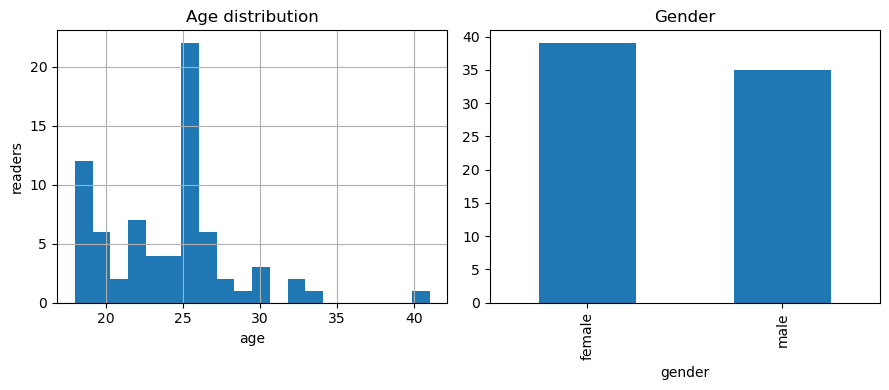

In [5]:
fig, ax = plt.subplots(1, 2)
participants["age"].dropna().astype(float).hist(bins=20, ax=ax[0])
ax[0].set(title="Age distribution", xlabel="age", ylabel="readers")
participants["gender"].value_counts().plot.bar(ax=ax[1], title="Gender")
plt.tight_layout(); plt.show()


## 3. Stimuli — the 12 texts

In [6]:
stimuli = read_potec(ROOT / "stimuli" / "stimuli" / "stimuli.tsv")
stimuli[["text_id", "text_domain", "headline", "source"]]


,text_id,text_domain,headline,source
0,p0,physics,Zyklotron,"W. Demtröder: Experimentalphysik 4, Springer, ..."
1,b0,biology,Gelelektrophorese,"Ableitner, Oksana: Einführung in die Molekular..."
2,p3,physics,Das Quarkmodell,"W. Demtröder: Experimentalphysik 4, Springer, ..."
3,b2,biology,Mineralstoffaufnahme durch das Wurzelsystem,"Townsend et al: Ökologie, Springer, 2003."
4,b1,biology,Homologe Rekombinationsreparatur,"J. Graw: Genetik, Springer, 2015."
5,p2,physics,Photonische Kristalle,"W. Demtröder: Experimentalphysik 2, Springer, ..."
6,b4,biology,Aufrechterhaltung eines kontinuierlichen Expor...,Boujard et al. (2014): Zell- und Molekularbiol...
7,b3,biology,Aktinbindende Motorproteine,Boujard et al. (2014): Zell- und Molekularbiol...
8,p1,physics,Mößbauereffekt,"W. Demtröder: Experimentalphysik 3, Springer, ..."
9,b5,biology,Prionen,Boujard et al. (2014): Zell- und Molekularbiol...


In [7]:
# Each text has 3 text-comprehension (tq) + 3 background-knowledge (bq) multiple-choice questions.
print("texts per domain:")
print(stimuli["text_domain"].value_counts())


texts per domain:
text_domain
physics    6
biology    6
Name: count, dtype: int64


## 4. Word features (psycholinguistic predictors)

Per-text, per-word features: length, syllables, PoS, frequency measures, orthographic neighbours,
technical-term flags, and (buggy) surprisal estimates from several LMs.

In [8]:
wf_b0 = read_potec(WF / "word_features_b0.tsv")
print("text b0:", wf_b0.shape, "words x features")
print("\nfeature columns:")
print(list(wf_b0.columns))
wf_b0.head()


text b0: (149, 71) words x features

feature columns:
['word', 'word_with_punct', 'word_index_in_text', 'word_index_in_sent', 'sent_index_in_text', 'word_limit_char_indices', 'text_id', 'text_id_numeric', 'text_domain', 'text_domain_numeric', 'word_length', 'STTS_punctuation_before', 'STTS_punctuation_after', 'is_in_quote', 'is_in_parentheses', 'is_clause_beginning', 'is_sent_beginning', 'is_clause_end', 'is_sent_end', 'is_abbreviation', 'is_expert_technical_term', 'is_general_technical_term', 'contains_symbol', 'contains_hyphen', 'contains_abbreviation', 'STTS_PoS_tag', 'type', 'type_length_chars', 'PoS_tag', 'lemma', 'lemma_length_chars', 'syllables', 'type_length_syllables', 'annotated_type_frequency_normalized', 'type_frequency_normalized', 'lemma_frequency_normalized', 'familiarity_normalized', 'regularity_normalized', 'document_frequency_normalized', 'sentence_frequency_normalized', 'cumulative_syllable_corpus_frequency_normalized', 'cumulative_syllable_lexicon_frequency_normaliz

,word,word_with_punct,word_index_in_text,word_index_in_sent,sent_index_in_text,word_limit_char_indices,text_id,text_id_numeric,text_domain,text_domain_numeric,word_length,STTS_punctuation_before,STTS_punctuation_after,is_in_quote,is_in_parentheses,is_clause_beginning,is_sent_beginning,is_clause_end,is_sent_end,is_abbreviation,is_expert_technical_term,is_general_technical_term,contains_symbol,contains_hyphen,contains_abbreviation,STTS_PoS_tag,type,type_length_chars,PoS_tag,lemma,...,cumulative_syllable_lexicon_frequency_normalized,cumulative_character_corpus_frequency_normalized,cumulative_character_lexicon_frequency_normalized,cumulative_character_bigram_corpus_frequency_normalized,cumulative_character_bigram_lexicon_frequency_normalized,cumulative_character_trigram_corpus_frequency_normalized,cumulative_character_trigram_lexicon_frequency_normalized,initial_letter_frequency_normalized,initial_bigram_frequency_normalized,initial_trigram_frequency_normalized,avg_cond_prob_in_bigrams,avg_cond_prob_in_trigrams,neighbors_coltheart_higher_freq_cum_freq_normalized,neighbors_coltheart_higher_freq_count_normalized,neighbors_coltheart_all_cum_freq_normalized,neighbors_coltheart_all_count_normalized,neighbors_levenshtein_higher_freq_cum_freq_normalized,neighbors_levenshtein_higher_freq_count_normalized,neighbors_levenshtein_all_cum_freq_normalized,neighbors_levenshtein_all_count_normalized,sent_surprisal_llama-7b,text_surprisal_llama-7b,sent_surprisal_llama-13b,text_surprisal_llama-13b,sent_surprisal_gpt2-base,text_surprisal_gpt2-base,sent_surprisal_gpt2-large,text_surprisal_gpt2-large,sent_surprisal_bert-base,text_surprisal_bert-base
0,Um,Um,1,1,1,"1,2",b0,0,biology,0,2,NaN,NaN,0,0,0,1,0,0,0,0,0,0,0,0,KOUI,Um,2.0,koui,um,...,7287.305542,1.127044e+05,2.682660e+05,37537.011546,3.811291e+04,37683.345460,37973.355936,5614.227325,736.574618,-0.008175,0.005076,0.019917,8655.896267,2.140429,8836.099533,44.520929,8655.896267,2.140429,8922.706320,50.086045,15.393944,14.881557,16.983448,17.055412,5.377072,5.377073,5.420597,5.420596,0.002685,0.001499
1,das,das,2,2,1,"3,5",b0,0,biology,0,3,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,ART,das,3.0,art,d,...,290.670297,7.340691e+05,1.662119e+06,216547.190476,1.696847e+05,215247.312040,124039.161294,110461.430317,19319.796313,7903.502872,0.028833,0.178985,0.000000,0.000000,15300.968354,34.674954,0.000000,0.000000,16474.051314,50.942217,3.839171,3.828737,3.882874,3.870950,3.198615,3.198614,3.249969,3.249982,0.014238,0.008061
2,Vorhandensein,Vorhandensein,3,3,1,"6,18",b0,0,biology,0,13,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NN,Vorhandensein,13.0,nn,Vorhandensein,...,35419.395714,4.743343e+06,1.030122e+07,853963.340019,1.494508e+06,350507.100559,462170.480912,10632.148039,3093.695144,1872.297467,0.002530,0.084008,0.000000,0.000000,0.024525,0.856172,0.000000,0.000000,0.694882,1.284258,8.582390,8.581095,10.377550,10.444736,8.940012,8.940015,8.231899,8.231875,3.908999,3.948390
3,der,der,4,4,1,"19,21",b0,0,biology,0,3,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,ART,der,3.0,art,d,...,19310.096833,1.332152e+06,2.711000e+06,487983.455471,5.357602e+05,398226.025843,178781.068331,110461.430317,53801.233108,27238.243229,0.129811,0.318759,0.000000,0.000000,25590.449781,36.815384,0.000000,0.000000,33289.199624,55.223076,2.252284,2.243800,2.907566,2.908132,3.067459,3.067449,2.216232,2.216226,1.612400,1.297863
4,Polymerasekettenreaktion-Produkte,Polymerasekettenreaktion-Produkte,5,5,1,"22,54",b0,0,biology,0,33,NaN,NaN,0,0,0,0,0,0,0,1,0,0,1,0,NN,Polymerasekettenreaktion-Produkte,33.0,nn,Polymerasekettenreaktion-Produkt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.161436,25.186792,23.061354,23.005802,30.968254,30.968224,24.896149,24.896055,31.875018,23.670716


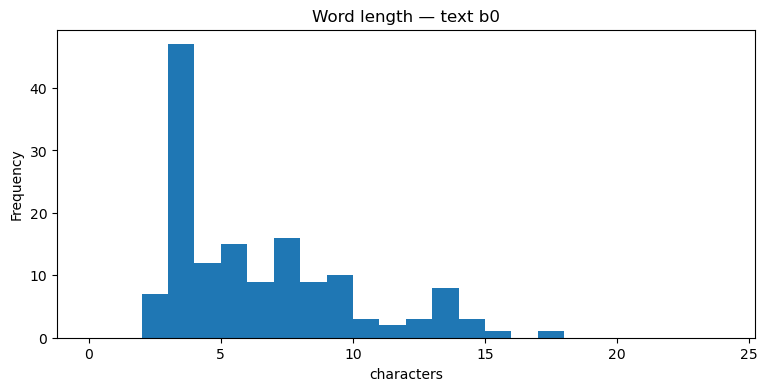

In [9]:
# Word length distribution for one text
wf_b0["word_length"].plot.hist(bins=range(0, 25),
    title="Word length — text b0", xlabel="characters"); plt.show()


## 5. Reading measures (the main analysis table)

Word-level eye-movement measures merged with word features + reader info, ordered by stimulus word order.
One file per (reader × text). Key measures (see `CODEBOOK.md` for full defs):

| col | meaning |
|---|---|
| `FFD` | first-fixation duration |
| `SFD` | single-fixation duration |
| `FPRT` | first-pass reading time (gaze duration) |
| `TFT` | total fixation time |
| `TFC` | total fixation count |
| `RPD_inc`/`RPD_exc` | regression-path duration (incl./excl.) |
| `Fix` | word fixated at all (0/1) |
| `FPReg` | first-pass regression out (0/1) |
| `RR` | re-reading (0/1) |


In [10]:
rm0 = read_potec(RM / "reader0_b0_merged.tsv")
print("reader0 x text b0:", rm0.shape)
measure_cols = ["word","FFD","SFD","FPRT","FRT","TFT","TFC","RPD_inc","Fix","FPReg","RR"]
rm0[measure_cols].head(12)


reader0 x text b0: (149, 107)


,word,FFD,SFD,FPRT,FRT,TFT,TFC,RPD_inc,Fix,FPReg,RR
0,Um,0,0,0,0,0,0,0,0,0,0
1,das,281,281,281,281,538,2,281,1,0,1
2,Vorhandensein,283,283,283,283,1050,4,283,1,0,1
3,der,0,0,0,0,0,0,0,0,0,0
4,Polymerasekettenreaktion-Produkte,394,0,4329,4329,7315,23,4329,1,0,1
5,feststellen,205,0,800,800,2274,9,800,1,0,1
6,zu,0,0,0,0,0,0,0,0,0,0
7,können,137,137,137,137,402,2,2688,1,1,1
8,verwendet,247,247,247,247,568,2,247,1,0,1
9,man,433,433,433,433,433,1,433,1,0,0


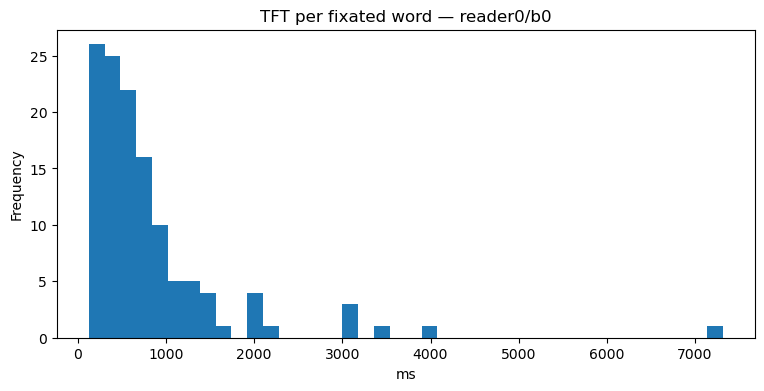

skip rate (TFT==0): 16.1%


In [11]:
# Distribution of total fixation time across words (skipped words -> 0)
fixated = rm0[rm0["TFT"] > 0]
fixated["TFT"].plot.hist(bins=40, title="TFT per fixated word — reader0/b0",
    xlabel="ms"); plt.show()
print(f"skip rate (TFT==0): {(rm0['TFT']==0).mean():.1%}")


## 6. Load the full corpus (all 900 reader×text files)

In [12]:
def load_all_reading_measures(cols=None):
    """Concatenate all 900 merged reading-measure files. ~1-2M rows; takes a bit."""
    frames = []
    for f in sorted(RM.glob("reader*_merged.tsv")):
        df = read_potec(f, usecols=cols)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

# Load a lean column subset to keep memory modest.
KEEP = ["reader_id","text_id","text_domain","word","word_length",
        "FFD","FPRT","TFT","TFC","Fix","FPReg","RR",
        "reader_discipline_numeric","level_of_studies_numeric",
        "expert_reading_label_numeric","mean_acc_tq","mean_acc_bq"]
rm_all = load_all_reading_measures(cols=KEEP)
print("full table:", rm_all.shape)
print("readers:", rm_all["reader_id"].nunique(), "| texts:", rm_all["text_id"].nunique())
rm_all.head()


full table: (142125, 17)
readers: 75 | texts: 12


,word,text_domain,word_length,FFD,FPRT,TFT,TFC,Fix,RR,FPReg,mean_acc_tq,mean_acc_bq,text_id,reader_id,reader_discipline_numeric,level_of_studies_numeric,expert_reading_label_numeric
0,Um,biology,2,0,0,0,0,0,0,0,0.332526,0.665052,b0,0,1,1,0
1,das,biology,3,281,281,538,2,1,1,0,0.332526,0.665052,b0,0,1,1,0
2,Vorhandensein,biology,13,283,283,1050,4,1,1,0,0.332526,0.665052,b0,0,1,1,0
3,der,biology,3,0,0,0,0,0,0,0,0.332526,0.665052,b0,0,1,1,0
4,Polymerasekettenreaktion-Produkte,biology,33,394,4329,7315,23,1,1,0,0.332526,0.665052,b0,0,1,1,0


## 7. The core effect — expert vs. non-expert reading

In [13]:
# expert_reading_label_numeric: 1 = reader discipline matches text domain (expert reading)
lab = {1: "expert reading", 0: "non-expert reading"}
g = rm_all.assign(reading=rm_all["expert_reading_label_numeric"].map(lab))

summary = g.groupby("reading").agg(
    mean_TFT=("TFT", "mean"),
    mean_FPRT=("FPRT", "mean"),
    skip_rate=("Fix", lambda s: 1 - s.mean()),
    regression_rate=("FPReg", "mean"),
)
summary


,mean_TFT,mean_FPRT,skip_rate,regression_rate
reading,,,,
expert reading,566.195881,238.351743,0.112432,0.160617
non-expert reading,663.266436,251.172337,0.094006,0.163050


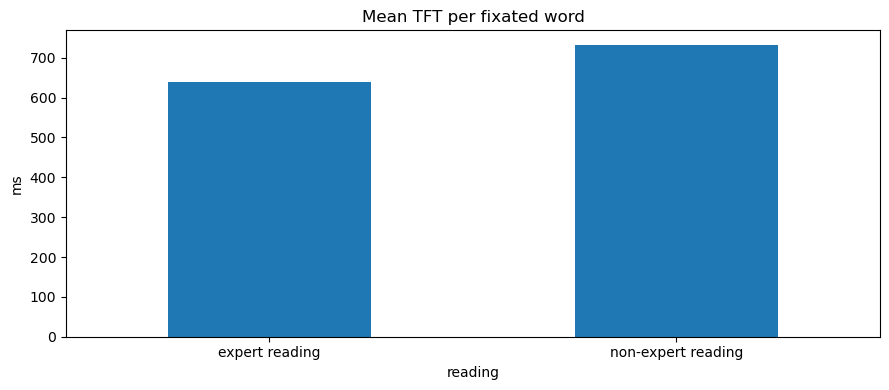

In [14]:
# Per-word total fixation time: experts read their own domain faster (lower TFT) typically
ax = (g[g["TFT"] > 0]
      .groupby("reading")["TFT"].mean()
      .plot.bar(title="Mean TFT per fixated word", ylabel="ms", rot=0))
plt.tight_layout(); plt.show()


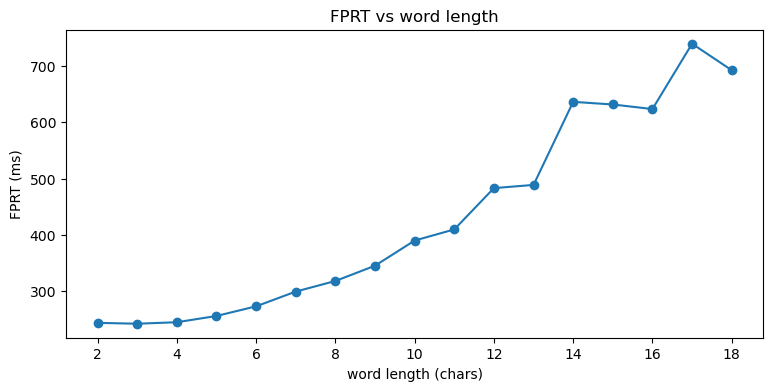

In [15]:
# Word-length effect on first-pass reading time (classic eye-movement result)
wl = (g[g["FPRT"] > 0]
      .groupby("word_length")["FPRT"].mean())
wl[wl.index.to_series().between(1, 18)].plot(
    marker="o", title="FPRT vs word length", xlabel="word length (chars)", ylabel="FPRT (ms)")
plt.show()


## 8. Comprehension & background-knowledge accuracy

In [16]:
acc = read_potec(ROOT / "participants" / "participant_response_accuracy.tsv")
print(acc.shape)
acc.head()


(900, 17)


,reader_id,reader_discipline,reader_discipline_numeric,level_of_studies,level_of_studies_numeric,text_id,text_domain,expert_reading_label,expert_reading_label_numeric,acc_tq_1,acc_tq_2,acc_tq_3,acc_bq_1,acc_bq_2,acc_bq_3,mean_acc_tq,mean_acc_bq
0,0,physics,1,graduate,1,b0,biology,non-expert-reading,0,1.0,1.0,0.0,0.0,0.0,1.0,0.666667,0.333333
1,0,physics,1,graduate,1,p5,physics,expert-reading,1,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.000000
2,0,physics,1,graduate,1,p4,physics,expert-reading,1,1.0,1.0,0.0,1.0,0.0,0.0,0.666667,0.333333
3,0,physics,1,graduate,1,p3,physics,expert-reading,1,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.333333
4,0,physics,1,graduate,1,p1,physics,expert-reading,1,1.0,1.0,1.0,1.0,1.0,0.0,1.000000,0.666667


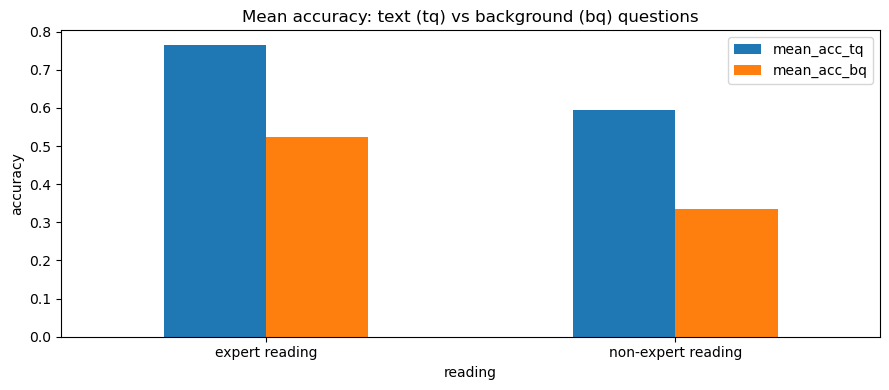

In [17]:
# Do experts answer background questions about their own domain better?
acc_lab = acc.assign(reading=acc["expert_reading_label_numeric"].map(
    {1: "expert reading", 0: "non-expert reading"}))
acc_lab.groupby("reading")[["mean_acc_tq", "mean_acc_bq"]].mean().plot.bar(
    rot=0, title="Mean accuracy: text (tq) vs background (bq) questions", ylabel="accuracy")
plt.tight_layout(); plt.show()


## 9. Scanpath — visualize one trial's reading sequence

fixations in scanpath: 412


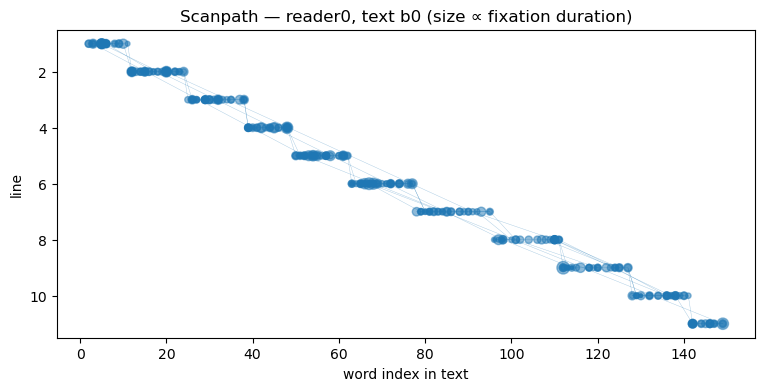

In [18]:
sp = read_potec(SP / "reader0_b0_merged_sp_rm.tsv")
print("fixations in scanpath:", len(sp))
# Plot fixation sequence by line over time; dot size ~ fixation duration
plt.scatter(sp["word_index_in_text"], sp["line"],
            s=sp["fixation_duration"] / 10, alpha=0.5)
plt.plot(sp["word_index_in_text"], sp["line"], lw=0.3, alpha=0.4)
plt.gca().invert_yaxis()
plt.title("Scanpath — reader0, text b0 (size ∝ fixation duration)")
plt.xlabel("word index in text"); plt.ylabel("line"); plt.show()


## 10. `pymovements` integration

PoTeC ships as a built-in public dataset in [`pymovements`](https://pymovements.readthedocs.io).
It can download the **raw gaze samples** from OSF and run gaze-event detection (fixations/saccades)
and visualizations — useful if you want to reprocess from raw rather than use the precomputed files here.

```python
import pymovements as pm

dataset = pm.Dataset("PoTeC", path="data/PoTeC")
dataset.download()      # pulls raw data + precomputed measures from OSF
dataset.load()          # loads gaze + reading_measures into memory

dataset.gaze                 # list of GazeDataFrame (raw samples per trial)
dataset.reading_measures     # word-level reading measures

# example processing pipeline on raw gaze:
dataset.pix2deg()                          # pixels -> degrees of visual angle
dataset.pos2vel()                          # position -> velocity
dataset.detect("ivt")                      # velocity-threshold fixation detection
# or: dataset.detect("idt")  -> dispersion-threshold
```

The cell below runs it **only if `pymovements` is installed and you opt in** (downloads ~GBs from OSF).

In [19]:
RUN_PYMOVEMENTS = False  # set True to download raw data from OSF (~large)

try:
    import pymovements as pm
    print("pymovements", pm.__version__)
    if RUN_PYMOVEMENTS:
        dataset = pm.Dataset("PoTeC", path="data/PoTeC")
        dataset.download()
        dataset.load()
        print("gaze trials:", len(dataset.gaze))
    else:
        # Inspect the dataset definition without downloading
        definition = pm.DatasetLibrary.get("PoTeC")
        print("long name:", definition.name)
        print("has resources defined:", bool(getattr(definition, "resources", None)))
except ImportError:
    print("pymovements not installed -> pip install pymovements")
except Exception as e:
    print("pymovements API note:", type(e).__name__, e)


pymovements 0.27.0
long name: PoTeC
has resources defined: True


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summary

- **Shape**: 75 readers × 12 texts = 900 trials (905 raw incl. reader 9's 5 trials).
- **Design**: discipline (phys/bio) × level (beginner/expert) between subjects × text domain within →
  the `expert_reading_label` flag marks the discipline-matches-domain cells.
- **Granularity**: raw samples → fixations → word-level reading measures → scanpaths, each merged with
  word features + reader info.
- **Caveat**: surprisal columns are buggy — don't use without contacting authors.
- **Reprocess from raw** via `pymovements` if you need custom fixation detection.
